In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

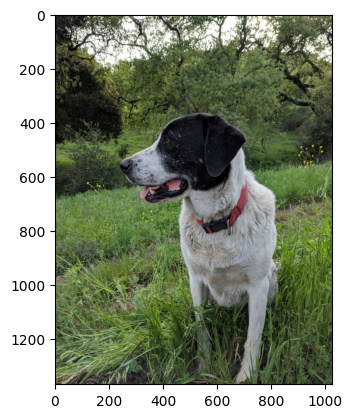

In [2]:
full=cv2.imread('../DATA/sammy.jpg')
full=cv2.cvtColor(full, cv2.COLOR_BGR2RGB)
plt.imshow(full)


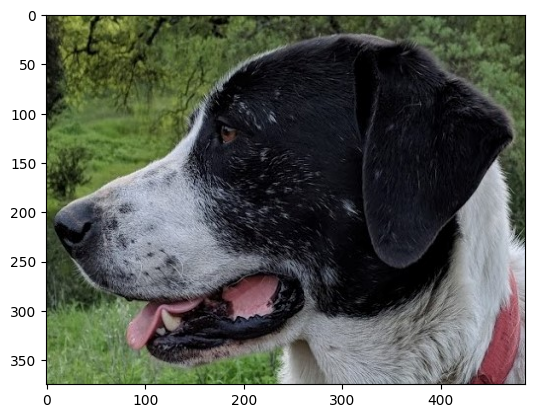

In [3]:
face=cv2.imread('../DATA/sammy_face.jpg')
face=cv2.cvtColor(face, cv2.COLOR_BGR2RGB)
plt.imshow(face)

In [4]:
face.shape


(375, 486, 3)

In [5]:
full.shape

(1367, 1025, 3)

In [6]:
# All the 6 methods for comparison in a list
# Note how we are using strings, later on we'll use the eval() function to convert to function
methods = ['cv2.TM_CCOEFF', 'cv2.TM_CCOEFF_NORMED', 'cv2.TM_CCORR','cv2.TM_CCORR_NORMED', 'cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']

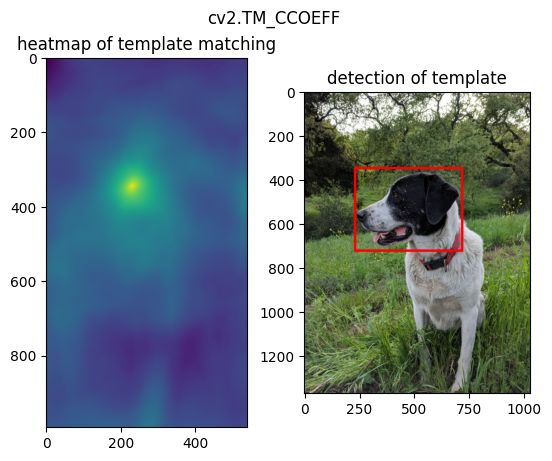

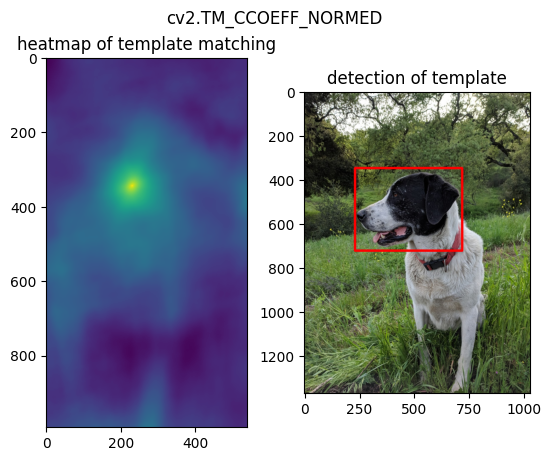

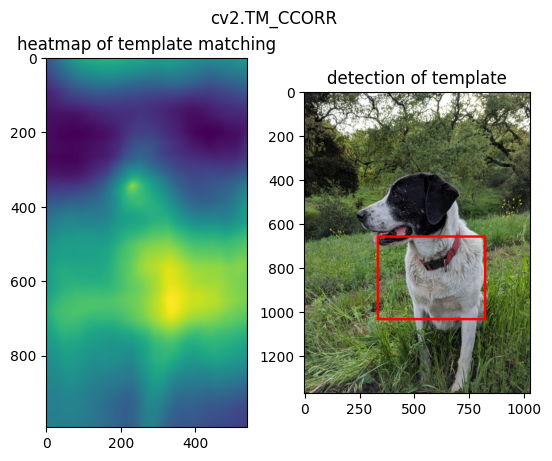

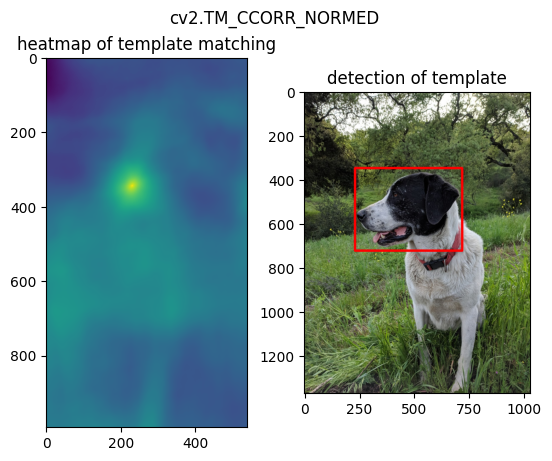

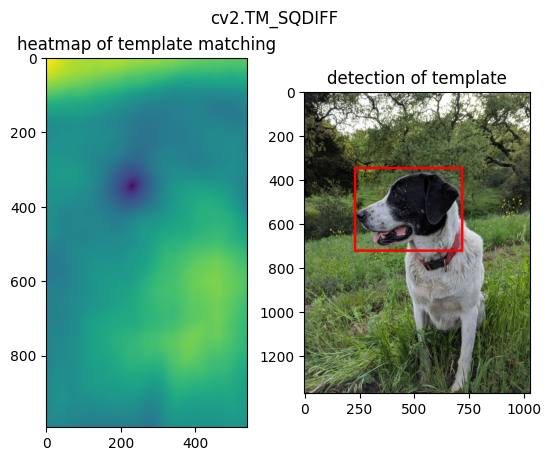

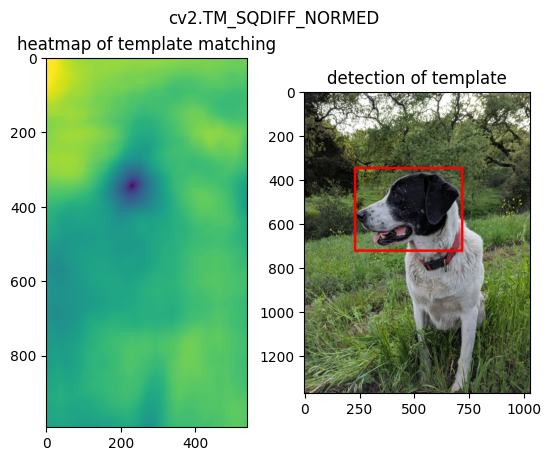

In [13]:
for m in methods:

    #create a copy
    full_copy=full.copy()

    method=eval(m)

    # template mathcing
    res=cv2.matchTemplate(full_copy,face,method)
    min_val, max_val, min_loc, max_loc=cv2.minMaxLoc(res)

    # if ker se metode razlikujejo, MINIMUM in MAX heat mapa računajo drugače (iversno)
    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_left=min_loc
    else:
        top_left=max_loc
    
    height,width,chanels=face.shape

    bottom_right=(top_left[0]+width,top_left[1]+height)

    cv2.rectangle(full_copy,top_left,bottom_right,(255,0,0),10)

    #plot and how the images
    plt.subplot(121)
    plt.imshow(res)
    plt.title('heatmap of template matching')

    plt.subplot(122)
    plt.imshow(full_copy)
    plt.title('detection of template')

    plt.suptitle(m)

    plt.show()

    print('\n')
    print('\n')

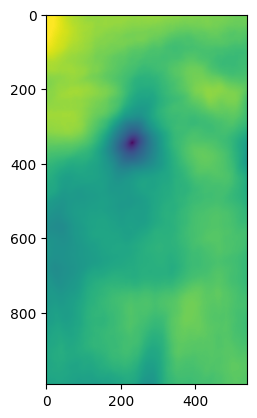

In [12]:
res=cv2.matchTemplate(full,face,cv2.TM_SQDIFF_NORMED)
plt.imshow(res)